# 03 Windows Log Anomaly Detection - LSTM Autoencoder

Train a dedicated **LSTM Autoencoder** for **windows logs**.

In [42]:

import os, json, joblib
import numpy as np
import pandas as pd
import sys
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense, Dropout
from tensorflow.keras.optimizers import Adam
sys.path.append(os.path.abspath(".."))
from src.preprocessing import clean_column_names, basic_log_preprocess, add_text_length_features, fill_numeric, encode_categoricals, keep_or_create_columns, scale_features, create_sequences

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
DATA_PATH = os.path.join(BASE_DIR, 'data/logs/windows/windows_logs.csv')
MODEL_DIR = os.path.join(BASE_DIR, 'models', 'windows_logs')
os.makedirs(MODEL_DIR, exist_ok=True)


## 1) Load dataset

In [43]:
df = pd.read_csv(DATA_PATH)

df.head()

,Level,Date and Time,Source,Event ID,Task Category
Information,11/19/2017 4:44:52 PM,Microsoft-Windows-Security-Auditing,4798,User Account Management,A user's local group membership was enumerated...
Information,11/19/2017 4:44:35 PM,Microsoft-Windows-Security-Auditing,4798,User Account Management,A user's local group membership was enumerated...
Information,11/19/2017 4:44:32 PM,Microsoft-Windows-Security-Auditing,4798,User Account Management,A user's local group membership was enumerated...
Information,11/19/2017 4:43:53 PM,Microsoft-Windows-Security-Auditing,4672,Special Logon,Special privileges assigned to new logon.\r\n\...
Information,11/19/2017 4:43:53 PM,Microsoft-Windows-Security-Auditing,4624,Logon,An account was successfully logged on.\r\n\r\n...


## 2) Configure columns
عدل القوائم دي حسب الداتا عندك.

In [44]:

timestamp_col = 'timestamp'
text_cols = ['source', 'level', 'task_category', 'account_name', 'process_name', 'message']
feature_candidates = ['event_id', 'logon_type', 'hour', 'dayofweek']
sequence_length = 10
lstm_units = 64
latent_dim = 32
dropout_rate = 0.2
learning_rate = 1e-3
batch_size = 32
epochs = 10
threshold_percentile = 95


In [45]:
df = df.rename(columns={
    'level': 'timestamp',
    'date_and_time': 'level',
    'source': 'event_id',
    'event_id': 'source',
    'task_category': 'message'
})

## 3) Preprocess

In [46]:

df = clean_column_names(df)
df = basic_log_preprocess(df, timestamp_col=timestamp_col)
df = add_text_length_features(df, text_cols)
df = fill_numeric(df)
df, encoders = encode_categoricals(df)

feature_cols = [c for c in feature_candidates if c in df.columns]
if not feature_cols:
    feature_cols = [c for c in df.columns if c != timestamp_col and pd.api.types.is_numeric_dtype(df[c])]

df = keep_or_create_columns(df, feature_cols)
X, scaler = scale_features(df, feature_cols)
X_seq = create_sequences(X, sequence_length=sequence_length)
print('Rows:', len(df), 'Features:', len(feature_cols), 'Sequences:', X_seq.shape)


Rows: 22124 Features: 1 Sequences: (22115, 10, 1)


## 4) Build model

In [47]:

n_features = X_seq.shape[2]
inputs = Input(shape=(sequence_length, n_features))
x = LSTM(lstm_units, activation='tanh', return_sequences=True)(inputs)
x = Dropout(dropout_rate)(x)
x = LSTM(latent_dim, activation='tanh', return_sequences=False)(x)
x = RepeatVector(sequence_length)(x)
x = LSTM(latent_dim, activation='tanh', return_sequences=True)(x)
x = Dropout(dropout_rate)(x)
x = LSTM(lstm_units, activation='tanh', return_sequences=True)(x)
outputs = TimeDistributed(Dense(n_features))(x)

model = Model(inputs, outputs)
model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')
model.summary()


Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 10, 1)]           0         
                                                                 
 lstm_8 (LSTM)               (None, 10, 64)            16896     
                                                                 
 dropout_4 (Dropout)         (None, 10, 64)            0         
                                                                 
 lstm_9 (LSTM)               (None, 32)                12416     
                                                                 
 repeat_vector_2 (RepeatVect  (None, 10, 32)           0         
 or)                                                             
                                                                 
 lstm_10 (LSTM)              (None, 10, 32)            8320      
                                                           

## 5) Train

In [48]:
history = model.fit(X_seq, X_seq, epochs=epochs, batch_size=batch_size, validation_split=0.1, shuffle=False)

Epoch 1/10
622/622 [==============================] - 13s 14ms/step - loss: 0.4861 - val_loss: 0.4754
Epoch 2/10
622/622 [==============================] - 7s 12ms/step - loss: 0.4284 - val_loss: 0.3956
Epoch 3/10
622/622 [==============================] - 7s 11ms/step - loss: 0.3884 - val_loss: 0.3674
Epoch 4/10
622/622 [==============================] - 11s 18ms/step - loss: 0.3240 - val_loss: 0.2700
Epoch 5/10
622/622 [==============================] - 11s 18ms/step - loss: 0.2326 - val_loss: 0.1975
Epoch 6/10
622/622 [==============================] - 12s 19ms/step - loss: 0.2016 - val_loss: 0.1712
Epoch 7/10
622/622 [==============================] - 13s 21ms/step - loss: 0.1643 - val_loss: 0.1288
Epoch 8/10
622/622 [==============================] - 12s 19ms/step - loss: 0.1307 - val_loss: 0.0929
Epoch 9/10
622/622 [==============================] - 10s 16ms/step - loss: 0.1054 - val_loss: 0.0835
Epoch 10/10
622/622 [==============================] - 8s 12ms/step - loss: 0.0867 -

In [49]:
import numpy as np

X_pred = model.predict(X_seq, verbose=0)
errors = np.mean(np.square(X_seq - X_pred), axis=(1, 2))

print("Min error:", errors.min())
print("Max error:", errors.max())
print("Mean error:", errors.mean())
print("Std error:", errors.std())

Min error: 0.00040314737380529295
Max error: 1.3725654440107806
Mean error: 0.062455175347013066
Std error: 0.12754227572959892


In [50]:
threshold_percentile = 95
threshold = np.percentile(errors, threshold_percentile)

print("Threshold:", threshold)

Threshold: 0.33231965863918606


In [51]:
y_pred = (errors > threshold).astype(int)

print("Number of anomalies:", y_pred.sum())
print("Anomaly ratio:", y_pred.mean())

Number of anomalies: 1088
Anomaly ratio: 0.04919737734569297


In [52]:
top_sorted = np.argsort(errors)[-20:][::-1]

for idx in top_sorted:
    print(f"\nIndex: {idx}, Error: {errors[idx]:.6f}")
    print(df.iloc[idx])


Index: 9582, Error: 1.372565
level                                                      10/18/2017 6:39:30 PM
date_and_time                                                                  1
source                                                                      4797
event_id                                                                      13
task_category                  An attempt was made to query the existence of ...
source_len                                                                     4
source_digit_count                                                             4
source_special_count                                                           0
level_len                                                                     21
level_digit_count                                                             13
level_special_count                                                            6
task_category_len                                                            34

## 6) Compute threshold and save artifacts

In [53]:
print(df.columns.tolist())

['level', 'date_and_time', 'source', 'event_id', 'task_category', 'source_len', 'source_digit_count', 'source_special_count', 'level_len', 'level_digit_count', 'level_special_count', 'task_category_len', 'task_category_digit_count', 'task_category_special_count']


In [54]:
print(df.head())

                             level  date_and_time  source  event_id  \
Information  11/19/2017 4:44:52 PM              1    4798        13   
Information  11/19/2017 4:44:35 PM              1    4798        13   
Information  11/19/2017 4:44:32 PM              1    4798        13   
Information  11/19/2017 4:43:53 PM              1    4672        11   
Information  11/19/2017 4:43:53 PM              1    4624         4   

                                                 task_category  source_len  \
Information  A user's local group membership was enumerated...           4   
Information  A user's local group membership was enumerated...           4   
Information  A user's local group membership was enumerated...           4   
Information  Special privileges assigned to new logon.\r\n\...           4   
Information  An account was successfully logged on.\r\n\r\n...           4   

             source_digit_count  source_special_count  level_len  \
Information                   4     

In [55]:
print(df.iloc[0].to_dict())

{'level': '11/19/2017 4:44:52 PM', 'date_and_time': 1, 'source': 4798, 'event_id': 13, 'task_category': "A user's local group membership was enumerated.\r\n\r\nSubject:\r\n\tSecurity ID:\t\tS-1-5-21-4190101832-3333789372-4192320479-1001\r\n\tAccount Name:\t\tsabyasachi\r\n\tAccount Domain:\t\tLAPTOP-CA15OR65\r\n\tLogon ID:\t\t0x659FAF7\r\n\r\nUser:\r\n\tSecurity ID:\t\tS-1-5-21-4190101832-3333789372-4192320479-1001\r\n\tAccount Name:\t\tsabyasachi\r\n\tAccount Domain:\t\tLAPTOP-CA15OR65\r\n\r\nProcess Information:\r\n\tProcess ID:\t\t0x28d4\r\n\tProcess Name:\t\tC:\\Windows\\System32\\mmc.exe", 'source_len': 4, 'source_digit_count': 4, 'source_special_count': 0, 'level_len': 21, 'level_digit_count': 13, 'level_special_count': 6, 'task_category_len': 434, 'task_category_digit_count': 95, 'task_category_special_count': 108}


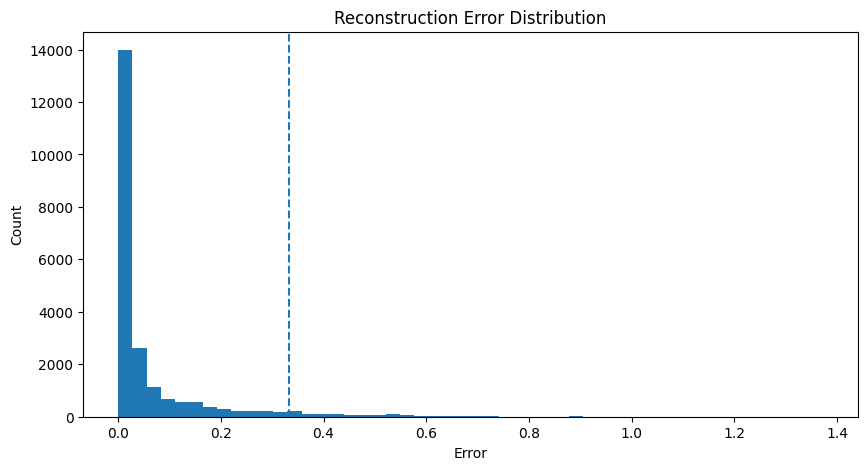

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(errors, bins=50)
plt.axvline(threshold, linestyle="--")
plt.title("Reconstruction Error Distribution")
plt.xlabel("Error")
plt.ylabel("Count")
plt.show()

In [56]:

recon = model.predict(X_seq, verbose=0)
mse = np.mean(np.power(X_seq - recon, 2), axis=(1,2))
threshold = float(np.percentile(mse, threshold_percentile))
print('Threshold:', threshold)

model.save(os.path.join(MODEL_DIR, 'windows_log_lstm_autoencoder.keras'))
joblib.dump(scaler, os.path.join(MODEL_DIR, 'windows_log_scaler.joblib'))
config = {
    'source': 'windows',
    'timestamp_col': timestamp_col,
    'text_cols': text_cols,
    'feature_cols': feature_cols,
    'sequence_length': sequence_length,
    'lstm_units': lstm_units,
    'latent_dim': latent_dim,
    'dropout_rate': dropout_rate,
    'learning_rate': learning_rate,
    'batch_size': batch_size,
    'epochs': epochs,
    'threshold_percentile': threshold_percentile,
    'threshold': threshold,
}
with open(os.path.join(MODEL_DIR, 'windows_log_model_config.json'), 'w', encoding='utf-8') as f:
    json.dump(config, f, indent=2)
print('Saved to', MODEL_DIR)


Threshold: 0.33231965863918606
Saved to f:\AI_Cyber_Defender_AI_Package_MultiLog\AI_Cyber_Defender_AI_Package_MultiLog\models\windows_logs
